There was a slight problem with loading the eagleSqlTools so I needed to add a few extra steps at the end**

### section 1

In [5]:
import sys
!{sys.executable} -m pip install eaglesqltools

Defaulting to user installation because normal site-packages is not writeable
DEPRECATION: unyt 2.8.0 has a non-standard dependency specifier numpy>="1.13.0". pip 23.3 will enforce this behaviour change. A possible replacement is to upgrade to a newer version of unyt or contact the author to suggest that they release a version with a conforming dependency specifiers. Discussion can be found at https://github.com/pypa/pip/issues/12063

[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [6]:
import sys
print(sys.version)
print(sys.executable)

3.10.2 (main, Jan 25 2022, 10:08:04) [GCC 8.5.0 20210514 (Red Hat 8.5.0-4)]
/cita/modules/python/3.10.2/bin/python


In [7]:
import eagleSqlTools as sql

In [8]:
username = 'qpr278'
password = 'AU99wus7'
con = sql.connect(username, password=password)

In [5]:
query="""SELECT MassType_Star as stellar_mass,
StarFormationRate as SFR
FROM RefL0100N1504_SubHalo
WHERE SnapNum = 28"""

In [6]:
data = sql.execute_query(con,query)

In [7]:
import matplotlib.pyplot as plt
import numpy as np

In [8]:
stellar_mass = data['stellar_mass']
SFR = data['SFR']

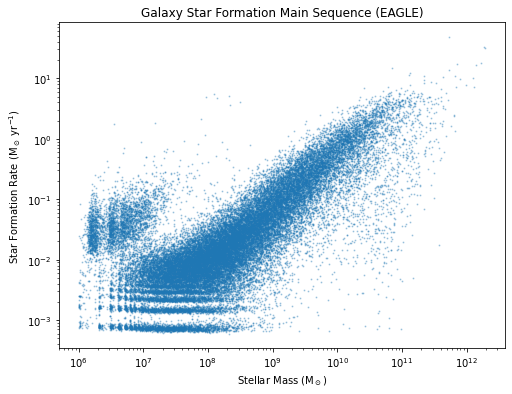

In [9]:
#making scatter plot of the data points

plt.figure(figsize=(8, 6))
plt.scatter(stellar_mass, SFR, s=1, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass (M$_\odot$)')
plt.ylabel('Star Formation Rate (M$_\odot$ yr$^{-1}$)')
plt.title('Galaxy Star Formation Main Sequence (EAGLE)')
plt.savefig('eagle_scatter.pdf')
plt.show()

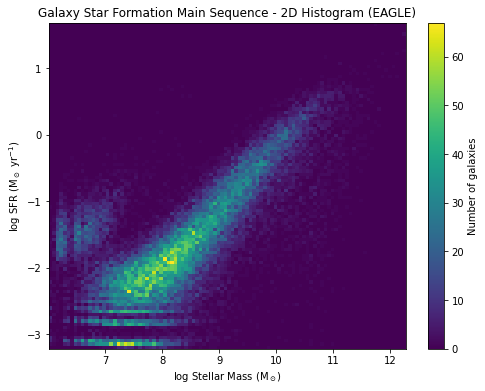

In [10]:
# Making histogram for the same information as above

# Filter out zeros for log scale
mask = (stellar_mass > 0) & (SFR > 0)

plt.figure(figsize=(8, 6))
plt.hist2d(np.log10(stellar_mass[mask]), np.log10(SFR[mask]), 
           bins=100, cmap='viridis')
plt.colorbar(label='Number of galaxies')
plt.xlabel('log Stellar Mass (M$_\odot$)')
plt.ylabel('log SFR (M$_\odot$ yr$^{-1}$)')
plt.title('Galaxy Star Formation Main Sequence - 2D Histogram (EAGLE)')
plt.savefig('eagle_histogram.pdf')
plt.show()

plotting line of best fit and deviations from it

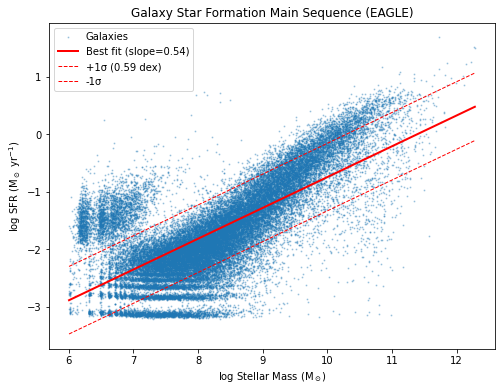

Slope: 0.54
Scatter: 0.59 dex


In [11]:
# Filter out zeros for log scale
mask = (stellar_mass > 0) & (SFR > 0)
log_mass = np.log10(stellar_mass[mask])
log_sfr = np.log10(SFR[mask])

# Line of best fit
coeffs = np.polyfit(log_mass, log_sfr, 1)
best_fit = np.poly1d(coeffs)
x_line = np.linspace(log_mass.min(), log_mass.max(), 100)

# Calculate scatter/deviation from the line
residuals = log_sfr - best_fit(log_mass)
scatter = np.std(residuals)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(log_mass, log_sfr, s=1, alpha=0.3, label='Galaxies')
plt.plot(x_line, best_fit(x_line), 'r-', linewidth=2, label=f'Best fit (slope={coeffs[0]:.2f})')
plt.plot(x_line, best_fit(x_line) + scatter, 'r--', linewidth=1, label=f'+1σ ({scatter:.2f} dex)')
plt.plot(x_line, best_fit(x_line) - scatter, 'r--', linewidth=1, label=f'-1σ')
plt.xlabel('log Stellar Mass (M$_\odot$)')
plt.ylabel('log SFR (M$_\odot$ yr$^{-1}$)')
plt.title('Galaxy Star Formation Main Sequence (EAGLE)')
plt.legend()
plt.savefig('eagle_scatter_bestfit.pdf')
plt.show()

print(f"Slope: {coeffs[0]:.2f}")
print(f"Scatter: {scatter:.2f} dex")

### SECTION 2

In [12]:
query2 = """SELECT MassType_Star as stellar_mass,
            StarFormationRate as SFR
            FROM RefL0100N1504_SubHalo
            WHERE Redshift > 0 AND Redshift < 0.5"""

data2 = sql.execute_query(con, query2)

In [13]:
# compare the number of galaxies
print(f"Section 1 galaxies (z=0): {len(data)}")
print(f"Section 2 galaxies (0 < z < 0.5): {len(data2)}")

Section 1 galaxies (z=0): 2275510
Section 2 galaxies (0 < z < 0.5): 11819412


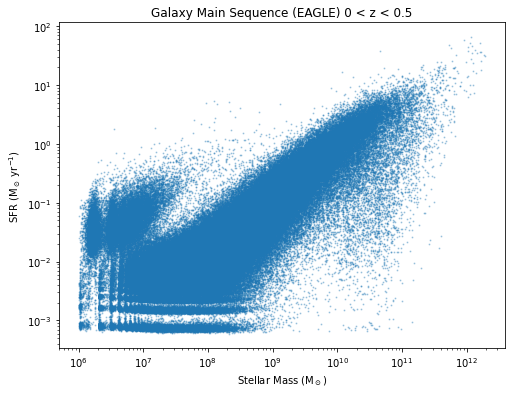

In [14]:
# making plot
stellar_mass2 = data2['stellar_mass']
SFR2 = data2['SFR']

plt.figure(figsize=(8, 6))
plt.scatter(stellar_mass2, SFR2, s=1, alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Stellar Mass (M$_\odot$)')
plt.ylabel('SFR (M$_\odot$ yr$^{-1}$)')
plt.title('Galaxy Main Sequence (EAGLE) 0 < z < 0.5')
plt.savefig('eagle_scatter_z05.pdf')
plt.show()

In [9]:
# 3. isolating the most massive galaxy and its direct descendants 

query_massive = """SELECT TOP 1 GalaxyID, TopLeafID, MassType_Star as stellar_mass
                   FROM RefL0100N1504_SubHalo
                   WHERE SnapNum = 28
                   ORDER BY MassType_Star DESC"""

most_massive = sql.execute_query(con, query_massive)
print(most_massive)

(21379521, 21379548, 1.9054253e+12)


in the output above, 
GalaxyID= 21379521
TopLeadID = 21379548
stellar_mass = 1.9054253e+12
since that is what we are outputting in SQL query (in SELECT clause)

In [10]:
galaxy_id = most_massive['GalaxyID']
topleaf_id = most_massive['TopLeafID']
print(f"GalaxyID: {galaxy_id}, TopLeafID: {topleaf_id}")


GalaxyID: 21379521, TopLeafID: 21379548


In [11]:
query_mainbranch = f"""SELECT GalaxyID, Redshift, MassType_Star as stellar_mass,
                       StarFormationRate as SFR
                       FROM RefL0100N1504_SubHalo
                       WHERE GalaxyID BETWEEN {galaxy_id} AND {topleaf_id}"""

mainbranch = sql.execute_query(con, query_mainbranch)
print(f"Number of snapshots in main branch: {len(mainbranch)}")

Number of snapshots in main branch: 28


In [13]:
# finding the descendants of the most massive galaxy
print(f"Number of galaxies in main branch: {len(mainbranch)}")
print("GalaxyIDs along main branch:")
print(mainbranch['GalaxyID']) # we print out the galaxy IDs of the descendants

Number of galaxies in main branch: 28
GalaxyIDs along main branch:
[21379521 21379522 21379523 21379524 21379525 21379526 21379527 21379528
 21379529 21379530 21379531 21379532 21379533 21379534 21379535 21379536
 21379537 21379538 21379539 21379540 21379541 21379542 21379543 21379544
 21379545 21379546 21379547 21379548]


/tmp/ipykernel_539394/4016920877.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.plot(mainbranch['Redshift'], np.log10(mainbranch['stellar_mass']), 'b-o', markersize=3)


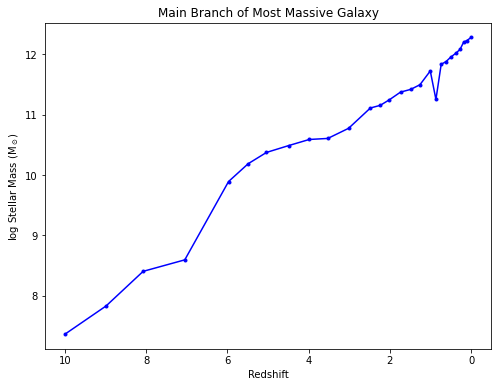

In [22]:
# This plot shows the stellar mass growth history of the most massive galaxy along its main branch over time.
plt.figure(figsize=(8,6))
plt.plot(mainbranch['Redshift'], np.log10(mainbranch['stellar_mass']), 'b-o', markersize=3)
plt.xlabel('Redshift')
plt.ylabel('log Stellar Mass (M$_\odot$)')
plt.title('Main Branch of Most Massive Galaxy')
plt.gca().invert_xaxis()
plt.savefig('mainbranch.pdf')
plt.show()

### Section 3

In [14]:
# 1. 
import requests
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":"11b150ed32a9c753b90d2a6ec16a38f3"} #enter your own API key here
def get(path, params=None):
# make HTTP GET request to path
    r = requests.get(path, params=params, headers=headers)
# raise exception if response code is not HTTP SUCCESS (200)
    r.raise_for_status()
    if r.headers['content-type'] == 'application/json':
        return r.json() # parse json responses automatically
    return r

In [15]:
# 2. 
z0url = 'http://www.tng-project.org/api/TNG100-1/snapshots/99/subhalos'
r = get(z0url)
# print out keys
r.keys()


dict_keys(['count', 'next', 'previous', 'results'])

In [16]:
# to find the number of galaxies
n_gal = r['count']
print(f"TNG100-1 galaxies at z=0: {n_gal}")

TNG100-1 galaxies at z=0: 4371211


EAGLE returned 2,275,510 subhalos at z=0, while TNG100-1 returned 4,371,211. The difference in counts reflects differences in simulation volume, resolution, and how each simulation defines and counts subhalos, rather than a physical difference in the number of galaxies in the universe.

In [17]:
# 3. 
# Limit to galaxies with some stellar mass to keep it manageable
subhalos = get(z0url, {'limit': 50000, 'mass_stars__gt': 0.01})
n_gal = len(subhalos['results'])
print(f"Number of galaxies retrieved: {n_gal}")

Number of galaxies retrieved: 47928


since it retrived less than the limit set, it means we have covered all galaxies.

In [18]:
# 4.
import numpy as np
from tqdm import tqdm
'''
get(subhalos['results'][0]['url'])
# prepare dict to hold result arrays
fields = ['id', 'sfr', 'mass_stars']
r = {}
for field in fields:
    if field == 'id':
        r[field] = np.empty(n_gal, dtype = int)
    else:
        r[field] = np.empty(n_gal, dtype = float)
# fill in dictionary with results from each galaxy
for i in tqdm(range(n_gal)):
    sub_i = get(subhalos['results'][i]['url'])
    # save fields to dictionary
    for field in fields:
        r[field][i] = sub_i[field]
'''
# the code in this cell was provided in the document shared, however, since there are 47,000+ galaxies,
# it would run for hours. to make it more managable, i will reduce the number of galaxies.

"\nget(subhalos['results'][0]['url'])\n# prepare dict to hold result arrays\nfields = ['id', 'sfr', 'mass_stars']\nr = {}\nfor field in fields:\n    if field == 'id':\n        r[field] = np.empty(n_gal, dtype = int)\n    else:\n        r[field] = np.empty(n_gal, dtype = float)\n# fill in dictionary with results from each galaxy\nfor i in tqdm(range(n_gal)):\n    sub_i = get(subhalos['results'][i]['url'])\n    # save fields to dictionary\n    for field in fields:\n        r[field][i] = sub_i[field]\n"

In [19]:
# Use a smaller sample for the plot - 1000 galaxies should be enough to see the main sequence
subhalos = get(z0url, {'limit': 1000, 'mass_stars__gt': 0.5}) 
n_gal = len(subhalos['results'])
print(f"Number of galaxies: {n_gal}")

Number of galaxies: 1000


In [20]:
import numpy as np
from tqdm import tqdm

get(subhalos['results'][0]['url'])
# prepare dict to hold result arrays
fields = ['id', 'sfr', 'mass_stars']
r = {}
for field in fields:
    if field == 'id':
        r[field] = np.empty(n_gal, dtype = int)
    else:
        r[field] = np.empty(n_gal, dtype = float)
# fill in dictionary with results from each galaxy
for i in tqdm(range(n_gal)):
    sub_i = get(subhalos['results'][i]['url'])
    # save fields to dictionary
    for field in fields:
        r[field][i] = sub_i[field]

100%|███████████████████████████████████████████████████████████████████████████████| 1000/1000 [11:24<00:00,  1.46it/s]


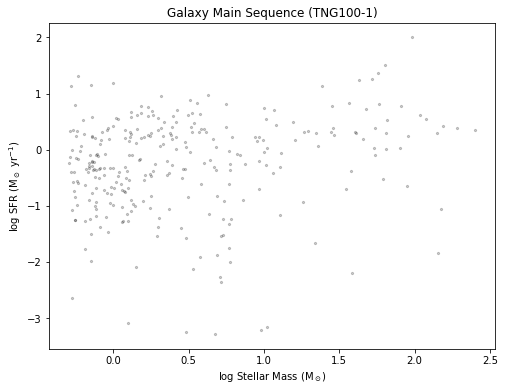

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
mask = (r['mass_stars'] > 0) & (r['sfr'] > 0)

plt.scatter(np.log10(r['mass_stars'][mask]), np.log10(r['sfr'][mask]), s=5, alpha=0.2, c='black')

plt.xlabel('log Stellar Mass (M$_\odot$)')
plt.ylabel('log SFR (M$_\odot$ yr$^{-1}$)')
plt.title('Galaxy Main Sequence (TNG100-1)')
plt.savefig('TNG_scatter.pdf')
plt.show()